#  Data Preprocessing With Python Workshop 
 
**Audience:** AIMS Students

---

## What We'll Cover

| # | Topic | Key Concepts |
|---|-------|-------------|
| 1 | **3D** | Effectiveness of data preprocessing |
| 2 | **Imaging** | Data Augmentation |
| 3 | **Text** | Tokenization, word embedding, wordcloud, Encoding (eg. one hot encoding) |

---

In [1]:
# Requires the latest pip
!pip install --upgrade pip

# Current stable release for CPU
!pip install tensorflow

  Using cached absl_py-2.4.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached protobuf-7.34.1-cp310-abi3-win_amd64.whl.metadata (595 bytes)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached urllib3-2.6.3-py3-none-any.whl.metadata (6.9 kB)
  Using cached namex-0.1.0-py3-none-any.whl.metadata (322 bytes)
  Using cached markdown_it_py-4.0.0-py3-none-any.whl.metadata (7.3 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
   ---------------------------------------- 0.0/350.6 MB ? eta -:--:--
   -----------------------------------

In [1]:
!pip install pandas matplotlib scikit-learn

  Using cached tzdata-2026.2-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   -- ------------------------------------- 0.8/11.3 MB 6.7 MB/s eta 0:00:02
   ------- -------------------------------- 2.1/11.3 MB 6.2 MB/s eta 0:00:02
   ------------- -------------------------- 3.9/11.3 MB 7.3 MB/s eta 0:00:02
   --------------------- ------------------ 6.0/11.3 MB 8.4 MB/s eta 0:00:01
   ----------------------------- ---------- 8.4/11.3 MB 9.0 MB/s eta 0:00:01
   ------------------------------------ --- 10.5/11.3 MB 9.1 MB/s eta 0:00:01
   ---------------------------------------- 11.3/11.3 MB 8.5 MB/s  0:00:01
   ---------------------------------------- 0.0/8.2 MB ? eta -

In [79]:
# %matplotlib notebook

import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from sklearn.metrics import accuracy_score

In [2]:
# Data Exploration

sample = pd.read_csv("sample.csv")

print(sample.head())

   31.377  332.04  -25.46
0  31.425  332.19 -25.455
1  31.427  332.27 -25.455
2  31.436  332.49 -25.449
3  31.449  332.56 -25.449
4  31.458  332.71 -25.439


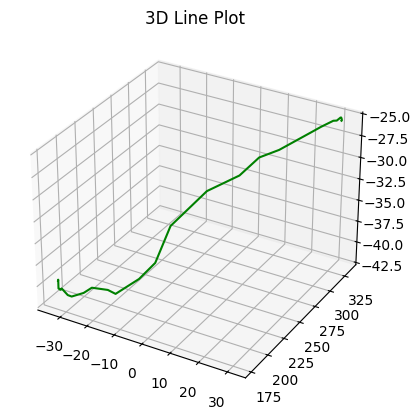

In [3]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot3D(sample.iloc[:, 0], sample.iloc[:, 1], sample.iloc[:, 2]  , 'green')
ax.set_title('3D Line Plot')
plt.show()

In [3]:
import plotly.graph_objects as go

# Create 3D line plot with Plotly
fig = go.Figure(data=[go.Scatter3d(
    x=sample.iloc[:, 0],
    y=sample.iloc[:, 1],
    z=sample.iloc[:, 2],
    mode='lines',
    line=dict(color='green', width=4)
)])

fig.update_layout(
    title='3D Line Plot - Interactive (Drag to Rotate)',
    scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Z'
    ),
    width=900,
    height=700
)

fig.show()

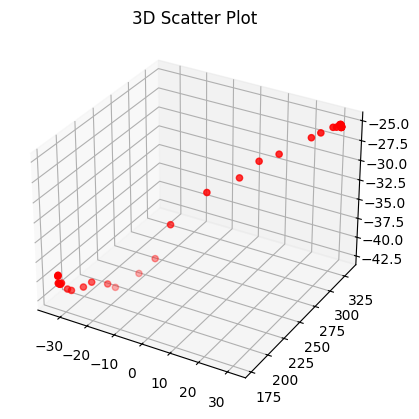

In [4]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(sample.iloc[:, 0], sample.iloc[:, 1], sample.iloc[:, 2], c='red', marker='o')
ax.set_title('3D Scatter Plot')
plt.show()

In [6]:
# directory where the Excel files are stored
directory = "digits_3d/training_data"

# List all files in the directory
excel_files = [f for f in os.listdir(directory) if f.endswith('.csv')]


In [8]:
len(excel_files)

1000

In [11]:
sample_file  = excel_files[0:1000:100]

In [18]:
sample__data = {}
for file in sample_file:
    df = pd.read_csv(os.path.join(directory, file ), header=None).to_numpy()
    parts = file.split('_')
    label = int(parts[1])  
    sample__data[label] = df

In [19]:
sample__data

{0: array([[-8.9283e+00,  3.0445e+02, -1.8469e+01],
        [-9.1475e+00,  3.0436e+02, -1.8585e+01],
        [-9.8688e+00,  3.0432e+02, -1.8896e+01],
        [-1.1690e+01,  3.0381e+02, -1.9305e+01],
        [-1.4821e+01,  3.0269e+02, -1.9284e+01],
        [-1.9585e+01,  3.0062e+02, -1.9579e+01],
        [-2.5511e+01,  2.9596e+02, -1.9006e+01],
        [-3.1590e+01,  2.8791e+02, -1.8021e+01],
        [-3.6297e+01,  2.7538e+02, -1.9003e+01],
        [-3.7797e+01,  2.6415e+02, -1.8385e+01],
        [-3.7070e+01,  2.5271e+02, -1.7931e+01],
        [-3.5457e+01,  2.4430e+02, -1.7759e+01],
        [-3.1162e+01,  2.3187e+02, -1.7103e+01],
        [-2.5458e+01,  2.2183e+02, -1.7138e+01],
        [-1.8214e+01,  2.1530e+02, -1.7494e+01],
        [-9.0252e+00,  2.1238e+02, -1.8352e+01],
        [-1.6570e-02,  2.1187e+02, -1.9287e+01],
        [ 9.0706e+00,  2.1586e+02, -2.0883e+01],
        [ 1.5807e+01,  2.2191e+02, -2.2263e+01],
        [ 2.0268e+01,  2.3192e+02, -2.2562e+01],
        [ 2.1856e

In [20]:
# Plot each digit in sample__data with labels as titles
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Create subplots for each digit
fig = make_subplots(
    rows=2, cols=5,
    specs=[[{'type': 'scatter3d'} for _ in range(5)] for _ in range(2)],
    subplot_titles=[f'Digit {label}' for label in sorted(sample__data.keys())]
)

# Add traces for each digit
row, col = 1, 1
for label in sorted(sample__data.keys()):
    data = sample__data[label]

    fig.add_trace(
        go.Scatter3d(
            x=data[:, 0],
            y=data[:, 1],
            z=data[:, 2],
            mode='lines',
            line=dict(color='blue', width=3),
            name=f'Digit {label}'
        ),
        row=row, col=col
    )

    col += 1
    if col > 5:
        col = 1
        row += 1

# Update layout
fig.update_layout(
    title='3D Handwritten Digits - Sample Data',
    height=800,
    showlegend=False
)

# Update all 3D scenes
for i in range(1, 11):  # 10 subplots
    fig.update_scenes(
        dict(
            xaxis_title='X',
            yaxis_title='Y',
            zaxis_title='Z'
        ),
        row=(i-1)//5 + 1,
        col=(i-1)%5 + 1
    )

fig.show()

In [38]:
# Zero Padding and Dataset Creation
# maximum length of the sequences
max_length = max(len(data) for data in sample__data.values())
padded_sample_data = {}

for label, data in sample__data.items():
    current_len = data.shape[0]
    if current_len < max_length:
        # Pad with zeros along the first axis (number of points)
        padding = np.zeros((max_length - current_len, data.shape[1]))
        padded_data = np.vstack([data, padding])
    else:
        # Trim if longer than max_length
        padded_data = data[:max_length, :]
    padded_sample_data[label] = padded_data

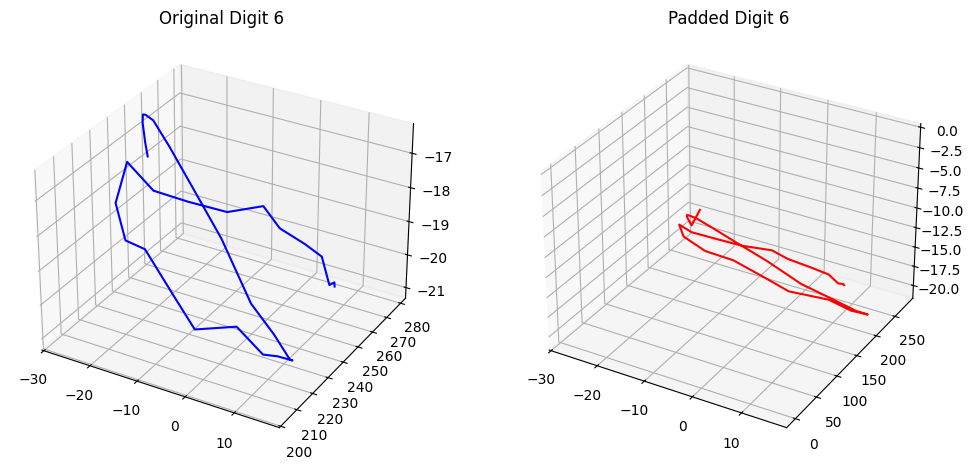

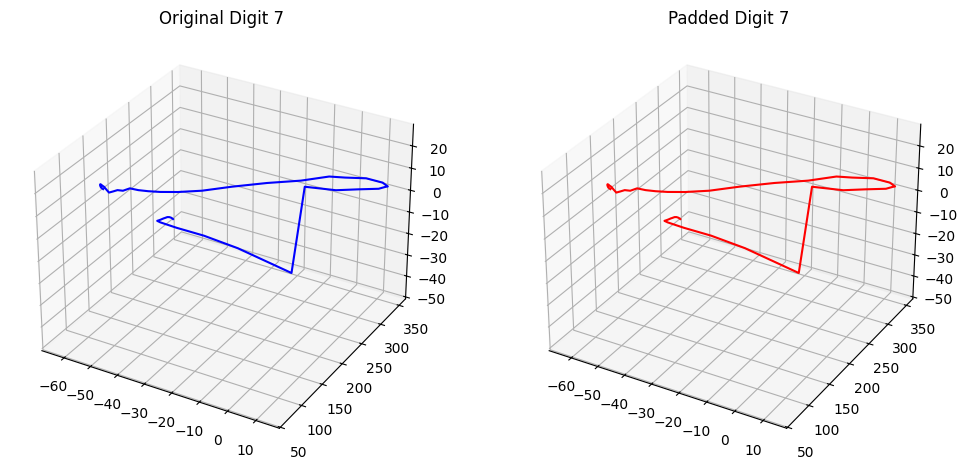

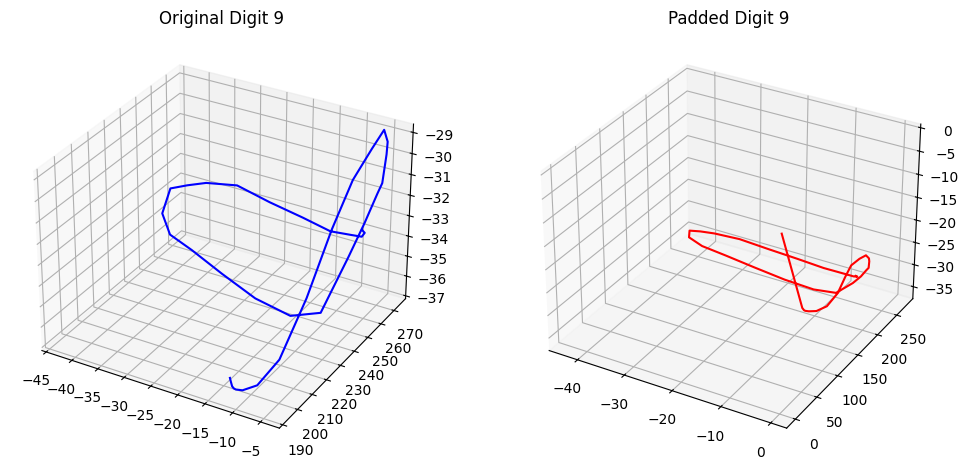

In [39]:
# Plot 3 randomly selected digits from the padded_sample_data and original sample__data to compare the effect of padding
import random   
random_labels = random.sample(list(sample__data.keys()), 3) 
for label in random_labels:
    original_data = sample__data[label]
    padded_data = padded_sample_data[label]

    fig = plt.figure(figsize=(12, 6))

    # Original Data
    ax1 = fig.add_subplot(121, projection='3d')
    ax1.plot3D(original_data[:, 0], original_data[:, 1], original_data[:, 2], 'blue')
    ax1.set_title(f'Original Digit {label}')

    # Padded Data
    ax2 = fig.add_subplot(122, projection='3d')
    ax2.plot3D(padded_data[:, 0], padded_data[:, 1], padded_data[:, 2], 'red')
    ax2.set_title(f'Padded Digit {label}')

    plt.show()

In [40]:
print(original_data.shape)   
print(padded_data.shape)

(38, 3)
(50, 3)


In [41]:
def pad_seq(X, max_len):
    current_len = X.shape[0]
    if current_len < max_len:
        # Pad with zeros along the first axis (number of points)
        padding = np.zeros((max_len - current_len, X.shape[1]))
        padded_data = np.vstack([X, padding])
    else:
        # Trim if longer than max_len    
        padded_data = X[:max_len, :]
    return padded_data

In [44]:
all_pad = [pad_seq(sample__data[label], max_length) for label in sample__data]

In [45]:
all_pad = np.array(all_pad)

In [46]:
all_pad.shape

(10, 50, 3)

In [47]:
flattened_x = all_pad.reshape(all_pad.shape[0], -1)

In [48]:
flattened_x.shape

(10, 150)

In [57]:
def processed_data(X, y):
    # Finding maximum length of data (number of points in each sequence)
    max_len = max([x.shape[0] for x in X])

    #padding them to maximum length
    X_padded = [pad_seq(data, max_len) for data in X]

    X_padded = np.array(X_padded)
    #Reshaping data to (1000,222,3)
    X_flat =  X_padded.reshape(X_padded.shape[0], -1)

    indices = np.arange(X_flat.shape[0])  # Generate an array of indices
    np.random.shuffle(indices)  # Shuffle the indices

    X_flat_shuffled = X_flat[indices]  # Apply the shuffled indices to X_flat
    y_shuffled = y[indices]
    return X_flat_shuffled, y_shuffled

In [58]:
def create_3d_dataset(directory):
    X = []  
    y = []  

    for file in os.listdir(directory):
        if file.endswith('.csv'):  
            parts = file.split('_')
            label = int(parts[1])  
            y.append(label)
            
            file_path = os.path.join(directory , file)
            data = pd.read_csv(file_path, header=None).to_numpy()
            X.append(data)
    
    y = np.array(y)
    
    X,y = processed_data(X,y)
    return X, y

In [62]:
X , y = create_3d_dataset(directory)

In [63]:
X.shape

(1000, 666)

In [53]:
# Inspection 
X_data = []
for file in os.listdir(directory):
    if file.endswith('.csv'):  
        file_path = os.path.join(directory , file)
        data = pd.read_csv(file_path, header=None).to_numpy()
        X_data.append(data)

In [56]:
max_len = max([x.shape[0] for x in X_data])
print("Maximum length:", max_len)


Maximum length: 222


In [65]:
# Data Splitting 
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
import RF_model

Model = RF_model.RandomForestFromScratch()

Model.fit(X_train, y_train)


In [67]:
# Evaluation on test set
y_pred = Model.predict(X_test)

In [68]:
y_pred

array([0, 2, 4, 4, 6, 6, 5, 0, 0, 7, 4, 0, 4, 0, 4, 8, 3, 8, 3, 4, 5, 5,
       2, 7, 5, 1, 6, 6, 3, 4, 2, 7, 0, 7, 0, 0, 4, 3, 8, 0, 6, 9, 7, 7,
       3, 7, 4, 5, 6, 9, 2, 6, 4, 4, 8, 1, 7, 0, 5, 6, 1, 8, 8, 0, 0, 8,
       6, 6, 6, 5, 6, 9, 9, 1, 3, 3, 2, 9, 8, 2, 1, 9, 1, 2, 9, 3, 1, 1,
       4, 5, 0, 3, 6, 4, 4, 9, 0, 2, 6, 6, 3, 7, 5, 4, 8, 0, 5, 1, 5, 0,
       8, 7, 7, 8, 4, 5, 6, 5, 0, 1, 1, 0, 0, 0, 6, 1, 9, 6, 4, 3, 2, 5,
       3, 9, 3, 2, 9, 3, 8, 1, 7, 9, 0, 3, 9, 4, 1, 7, 7, 7, 7, 6, 5, 0,
       0, 6, 8, 5, 5, 5, 1, 1, 2, 2, 0, 8, 2, 8, 2, 0, 2, 5, 5, 6, 3, 2,
       9, 5, 7, 1, 7, 0, 0, 4, 2, 4, 1, 8, 3, 7, 8, 5, 8, 3, 6, 7, 8, 6,
       3, 5])

In [69]:
y_test

array([0, 3, 4, 4, 6, 6, 5, 8, 0, 7, 4, 0, 4, 0, 4, 8, 1, 8, 2, 4, 5, 5,
       2, 7, 5, 1, 0, 6, 3, 9, 2, 7, 0, 7, 6, 0, 8, 3, 8, 0, 6, 9, 7, 7,
       9, 7, 4, 5, 6, 9, 2, 6, 9, 4, 8, 6, 7, 0, 5, 6, 7, 8, 8, 0, 0, 8,
       6, 6, 6, 5, 0, 9, 9, 1, 3, 3, 2, 9, 8, 2, 3, 9, 1, 2, 9, 3, 1, 1,
       4, 5, 7, 7, 6, 4, 4, 9, 0, 2, 6, 6, 3, 7, 4, 2, 8, 0, 5, 1, 5, 4,
       0, 2, 7, 8, 4, 5, 6, 5, 0, 1, 1, 0, 0, 0, 6, 1, 9, 0, 4, 3, 3, 9,
       3, 9, 4, 2, 9, 3, 8, 1, 7, 9, 0, 3, 9, 7, 1, 7, 7, 7, 7, 6, 8, 0,
       0, 6, 8, 8, 5, 5, 1, 1, 2, 2, 6, 8, 2, 8, 3, 0, 2, 4, 5, 6, 9, 2,
       9, 5, 7, 1, 7, 0, 0, 4, 2, 8, 7, 8, 7, 7, 8, 5, 8, 3, 6, 7, 8, 6,
       3, 5])

In [73]:
# Accuracy and Confusion Matrix
accuracy = np.mean(y_pred == y_test)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.8250


In [81]:
# Test Accuracy using sklearn's accuracy_score
accuracy_sklearn = accuracy_score(y_test, y_pred)
print(f"Accuracy (sklearn): {accuracy_sklearn:.4f}")

Accuracy (sklearn): 0.8250


In [75]:
# Simple text-based confusion matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix (Text):")
print("Predicted →")
print("Actual ↓")
print(cm)
print()

Confusion Matrix (Text):
Predicted →
Actual ↓
[[22  0  0  0  0  0  3  0  1  0]
 [ 0 14  0  1  0  0  0  0  0  0]
 [ 0  0 14  1  1  0  0  1  0  0]
 [ 0  1  3 12  0  0  0  0  0  0]
 [ 1  0  0  1 14  2  0  0  0  0]
 [ 0  0  0  0  0 18  0  0  0  0]
 [ 2  1  0  0  0  0 20  0  0  0]
 [ 1  2  0  2  1  0  0 19  0  0]
 [ 1  0  0  0  2  2  0  0 18  0]
 [ 0  0  0  2  2  1  0  0  0 14]]



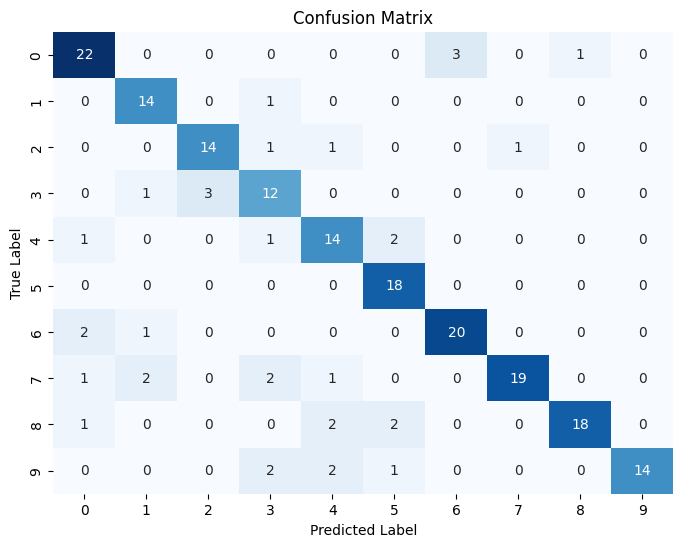

In [78]:
# Plot the confusion matrix using seaborn
import seaborn as sns   

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix')   
plt.xlabel('Predicted Label')
plt.ylabel('True Label')    
plt.show()

In [82]:
# KNN

from sklearn.neighbors import KNeighborsClassifier

In [90]:
# List of KNN configurations to try
knn_params = [
    {'n_neighbors': 1, 'weights': 'uniform', 'metric': 'euclidean'},
    {'n_neighbors': 5, 'weights': 'uniform', 'metric': 'euclidean'},
    {'n_neighbors': 7, 'weights': 'uniform', 'metric': 'euclidean'},
    {'n_neighbors': 1, 'weights': 'distance', 'metric': 'euclidean'},
    {'n_neighbors': 5, 'weights': 'distance', 'metric': 'euclidean'},
    {'n_neighbors': 7, 'weights': 'distance', 'metric': 'euclidean'},
    {'n_neighbors': 1, 'weights': 'uniform', 'metric': 'manhattan'},
    {'n_neighbors': 5, 'weights': 'uniform', 'metric': 'manhattan'},
    {'n_neighbors': 7, 'weights': 'uniform', 'metric': 'manhattan'},
    {'n_neighbors': 1, 'weights': 'distance', 'metric': 'manhattan'},
    {'n_neighbors': 5, 'weights': 'distance', 'metric': 'manhattan'},
    {'n_neighbors': 7, 'weights': 'distance', 'metric': 'manhattan'},
]

# Iterate through each configuration
results = []
for params in knn_params:
    # Initialize the KNN classifier with given parameters
    knn = KNeighborsClassifier(**params)
    
    # Train the KNN model
    knn.fit(X_train, y_train)
    
    # Make predictions
    y_train_pred = knn.predict(X_train)
    y_test_pred = knn.predict(X_test)
    
    # Evaluate the model's performance
    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    
    # Save results
    results.append({
        'params': params,
        'train_accuracy': train_accuracy,
        'test_accuracy': test_accuracy
    })

    # Print results for this configuration
    print(f"Parameters: {params}")
    print(f"Training Accuracy: {train_accuracy:.4f}")
    print(f"Testing Accuracy: {test_accuracy:.4f}")
    print('-' * 50)

# Summarize all results
print("\nSummary of Results:")
for result in results:
    print(f"Params: {result['params']} | Train Acc: {result['train_accuracy']:.4f} | Test Acc: {result['test_accuracy']:.4f}")


Parameters: {'n_neighbors': 1, 'weights': 'uniform', 'metric': 'euclidean'}
Training Accuracy: 1.0000
Testing Accuracy: 0.7450
--------------------------------------------------
Parameters: {'n_neighbors': 5, 'weights': 'uniform', 'metric': 'euclidean'}
Training Accuracy: 0.8350
Testing Accuracy: 0.7000
--------------------------------------------------
Parameters: {'n_neighbors': 7, 'weights': 'uniform', 'metric': 'euclidean'}
Training Accuracy: 0.7850
Testing Accuracy: 0.6750
--------------------------------------------------
Parameters: {'n_neighbors': 1, 'weights': 'distance', 'metric': 'euclidean'}
Training Accuracy: 1.0000
Testing Accuracy: 0.7450
--------------------------------------------------
Parameters: {'n_neighbors': 5, 'weights': 'distance', 'metric': 'euclidean'}
Training Accuracy: 1.0000
Testing Accuracy: 0.7450
--------------------------------------------------
Parameters: {'n_neighbors': 7, 'weights': 'distance', 'metric': 'euclidean'}
Training Accuracy: 1.0000
Testi

In [92]:
# SVM
from sklearn.svm import SVC

# List of SVM configurations to try
svm_params = [
    {'kernel': 'linear', 'C': 32},
    {'kernel': 'linear', 'C': 0.01},
    {'kernel': 'rbf', 'C': 1, 'gamma': 'scale'},
    {'kernel': 'rbf', 'C': 10, 'gamma': 0.01},
    {'kernel': 'poly', 'C': 5, 'degree': 10, 'gamma': 'scale'},
    {'kernel': 'sigmoid', 'C': 5, 'gamma': 'scale'}
]

# Iterate through each configuration
results = []
for params in svm_params:
    # Initialize the SVM classifier with given parameters
    svm = SVC(**params, random_state=42)
    
    # Train the SVM
    svm.fit(X_train, y_train)
    
    # Make predictions
    y_train_pred = svm.predict(X_train)
    y_test_pred = svm.predict(X_test)
    
    # Evaluate the model's performance
    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    
    # Save results
    results.append({
        'params': params,
        'train_accuracy': train_accuracy,
        'test_accuracy': test_accuracy
    })

    # Print results for this configuration
    print(f"Parameters: {params}")
    print(f"Training Accuracy: {train_accuracy:.4f}")
    print(f"Testing Accuracy: {test_accuracy:.4f}")
    print('-' * 50)

# Summarize all results
print("\nSummary of Results:")
for result in results:
    print(f"Params: {result['params']} | Train Acc: {result['train_accuracy']:.4f} | Test Acc: {result['test_accuracy']:.4f}")


Parameters: {'kernel': 'linear', 'C': 32}
Training Accuracy: 1.0000
Testing Accuracy: 0.6600
--------------------------------------------------
Parameters: {'kernel': 'linear', 'C': 0.01}
Training Accuracy: 1.0000
Testing Accuracy: 0.6600
--------------------------------------------------
Parameters: {'kernel': 'rbf', 'C': 1, 'gamma': 'scale'}
Training Accuracy: 0.6012
Testing Accuracy: 0.4750
--------------------------------------------------
Parameters: {'kernel': 'rbf', 'C': 10, 'gamma': 0.01}
Training Accuracy: 1.0000
Testing Accuracy: 0.0750
--------------------------------------------------
Parameters: {'kernel': 'poly', 'C': 5, 'degree': 10, 'gamma': 'scale'}
Training Accuracy: 0.5387
Testing Accuracy: 0.3250
--------------------------------------------------
Parameters: {'kernel': 'sigmoid', 'C': 5, 'gamma': 'scale'}
Training Accuracy: 0.4150
Testing Accuracy: 0.3300
--------------------------------------------------

Summary of Results:
Params: {'kernel': 'linear', 'C': 32} | 

In [111]:
flat = sample__data[0]

print(np.mean(flat[0], axis=0))

92.35090000000001


In [115]:
np.mean(flat[0:4,0])

np.float64(-9.90865)

In [116]:
# Interpolation of sequences to a fixed length (e.g., 100 points)
def interpolate_to_fixed_length(data, target_len=222):
    """
    data: numpy array of shape (N, D) e.g. (N, 3)
    returns: (target_len, D)
    """
    N, D = data.shape
    
    if N == target_len:
        return data

    # original positions
    x_old = np.linspace(0, 1, N)
    
    # new positions
    x_new = np.linspace(0, 1, target_len)

    # interpolate each dimension
    interpolated = np.zeros((target_len, D))
    for d in range(D):
        interpolated[:, d] = np.interp(x_new, x_old, data[:, d])

    return interpolated

In [117]:
flat = sample__data[0]

In [119]:
flat[0:4,]

array([[ -8.9283, 304.45  , -18.469 ],
       [ -9.1475, 304.36  , -18.585 ],
       [ -9.8688, 304.32  , -18.896 ],
       [-11.69  , 303.81  , -19.305 ]])

In [122]:
int_dat = interpolate_to_fixed_length(flat, target_len=222)

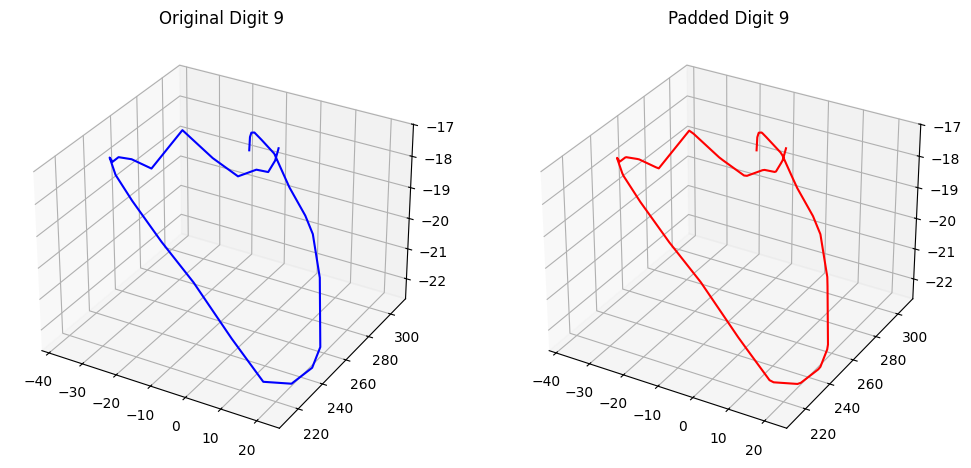

In [123]:
fig = plt.figure(figsize=(12, 6))

# Original Data
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot3D(flat[:, 0], flat[:, 1], flat[:, 2], 'blue')
ax1.set_title(f'Original Digit {label}')

# Padded Data
ax2 = fig.add_subplot(122, projection='3d')
ax2.plot3D(int_dat[:, 0], int_dat[:, 1], int_dat[:, 2], 'red')
ax2.set_title(f'Padded Digit {label}')

plt.show()

In [124]:
print(flat.shape)
print(int_dat.shape)

(32, 3)
(222, 3)


In [125]:
def proc_int_data(X, y):
    # Finding maximum length of data (number of points in each sequence)
    max_len = max([x.shape[0] for x in X])

    #padding them to maximum length
    X_padded = [interpolate_to_fixed_length(data, max_len) for data in X]

    X_padded = np.array(X_padded)
    #Reshaping data to (1000,222,3)
    X_flat =  X_padded.reshape(X_padded.shape[0], -1)

    indices = np.arange(X_flat.shape[0])  # Generate an array of indices
    np.random.shuffle(indices)  # Shuffle the indices

    X_flat_shuffled = X_flat[indices]  # Apply the shuffled indices to X_flat
    y_shuffled = y[indices]
    return X_flat_shuffled, y_shuffled

In [126]:
def create_3d_dat(directory):
    X = []  
    y = []  

    for file in os.listdir(directory):
        if file.endswith('.csv'):  
            parts = file.split('_')
            label = int(parts[1])  
            y.append(label)
            
            file_path = os.path.join(directory , file)
            data = pd.read_csv(file_path, header=None).to_numpy()
            X.append(data)
    
    y = np.array(y)
    
    X,y = proc_int_data(X,y)
    return X, y

In [127]:
x_new , y_new = create_3d_dat(directory)

In [128]:
X_train, X_test, y_train, y_test = train_test_split(x_new, y_new, test_size=0.2, random_state=42)
int_Model = RF_model.RandomForestFromScratch()

int_Model.fit(X_train, y_train)

# Evaluation on test set
y_pred = int_Model.predict(X_test)

# Test Accuracy using sklearn's accuracy_score
accuracy_sklearn = accuracy_score(y_test, y_pred)
print(f"Accuracy (sklearn): {accuracy_sklearn:.4f}")

Accuracy (sklearn): 0.9400


In [129]:
# List of KNN configurations to try
knn_params = [
    {'n_neighbors': 1, 'weights': 'uniform', 'metric': 'euclidean'},
    {'n_neighbors': 5, 'weights': 'uniform', 'metric': 'euclidean'},
    {'n_neighbors': 7, 'weights': 'uniform', 'metric': 'euclidean'},
    {'n_neighbors': 1, 'weights': 'distance', 'metric': 'euclidean'},
    {'n_neighbors': 5, 'weights': 'distance', 'metric': 'euclidean'},
    {'n_neighbors': 7, 'weights': 'distance', 'metric': 'euclidean'},
    {'n_neighbors': 1, 'weights': 'uniform', 'metric': 'manhattan'},
    {'n_neighbors': 5, 'weights': 'uniform', 'metric': 'manhattan'},
    {'n_neighbors': 7, 'weights': 'uniform', 'metric': 'manhattan'},
    {'n_neighbors': 1, 'weights': 'distance', 'metric': 'manhattan'},
    {'n_neighbors': 5, 'weights': 'distance', 'metric': 'manhattan'},
    {'n_neighbors': 7, 'weights': 'distance', 'metric': 'manhattan'},
]

# Iterate through each configuration
results = []
for params in knn_params:
    # Initialize the KNN classifier with given parameters
    knn = KNeighborsClassifier(**params)
    
    # Train the KNN model
    knn.fit(X_train, y_train)
    
    # Make predictions
    y_train_pred = knn.predict(X_train)
    y_test_pred = knn.predict(X_test)
    
    # Evaluate the model's performance
    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    
    # Save results
    results.append({
        'params': params,
        'train_accuracy': train_accuracy,
        'test_accuracy': test_accuracy
    })

    # Print results for this configuration
    print(f"Parameters: {params}")
    print(f"Training Accuracy: {train_accuracy:.4f}")
    print(f"Testing Accuracy: {test_accuracy:.4f}")
    print('-' * 50)

# Summarize all results
print("\nSummary of Results:")
for result in results:
    print(f"Params: {result['params']} | Train Acc: {result['train_accuracy']:.4f} | Test Acc: {result['test_accuracy']:.4f}")


Parameters: {'n_neighbors': 1, 'weights': 'uniform', 'metric': 'euclidean'}
Training Accuracy: 1.0000
Testing Accuracy: 0.9450
--------------------------------------------------
Parameters: {'n_neighbors': 5, 'weights': 'uniform', 'metric': 'euclidean'}
Training Accuracy: 0.9525
Testing Accuracy: 0.9050
--------------------------------------------------
Parameters: {'n_neighbors': 7, 'weights': 'uniform', 'metric': 'euclidean'}
Training Accuracy: 0.9413
Testing Accuracy: 0.8800
--------------------------------------------------
Parameters: {'n_neighbors': 1, 'weights': 'distance', 'metric': 'euclidean'}
Training Accuracy: 1.0000
Testing Accuracy: 0.9450
--------------------------------------------------
Parameters: {'n_neighbors': 5, 'weights': 'distance', 'metric': 'euclidean'}
Training Accuracy: 1.0000
Testing Accuracy: 0.9200
--------------------------------------------------
Parameters: {'n_neighbors': 7, 'weights': 'distance', 'metric': 'euclidean'}
Training Accuracy: 1.0000
Testi